Import Necessary Libraries

In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Basic Understanding of Data

In [47]:
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [49]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [50]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [51]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [52]:
df.shape

(7043, 21)

Data Cleaning


In [53]:
df=df.drop('customerID',axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [54]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges']

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

Identify missing values

In [55]:
df['TotalCharges'].isnull().sum()

np.int64(11)

Handle Missing Values


In [56]:
df['TotalCharges'].fillna(0,inplace=True)
df['TotalCharges']

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [57]:
df['TotalCharges'].isnull().sum()

np.int64(0)

EDA(Exploratory Data Analysis)

#Pie Chart [Churn Distribution]

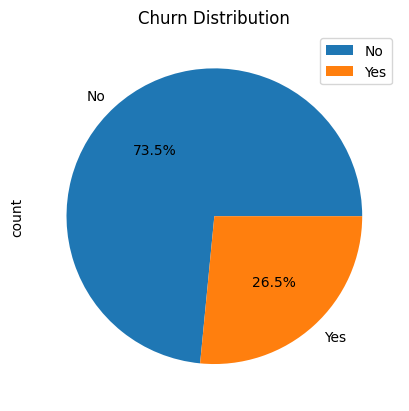

In [58]:
df['Churn'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Churn Distribution')
plt.legend()
plt.show()

#Countplot [Churn Vs Contract]

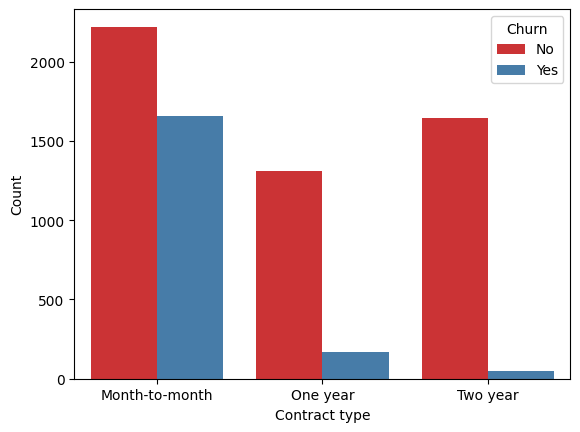

In [59]:
sns.countplot(data=df,x='Contract',hue='Churn',palette='Set1')
plt.xlabel('Contract type')
plt.ylabel('Count')
plt.show()

Boxplot [Churn Vs Monthly Charge]

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_12740\3558682503.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Churn',y='MonthlyCharges',palette='Set2')


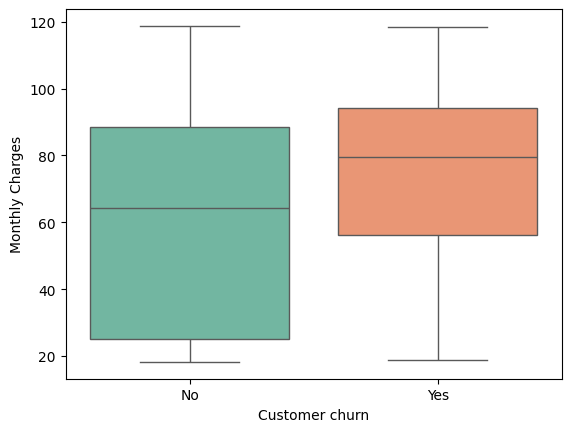

In [60]:
sns.boxplot(data=df,x='Churn',y='MonthlyCharges',palette='Set2')
plt.xlabel('Customer churn')
plt.ylabel('Monthly Charges')
plt.show()

Heatmap [Correlation]

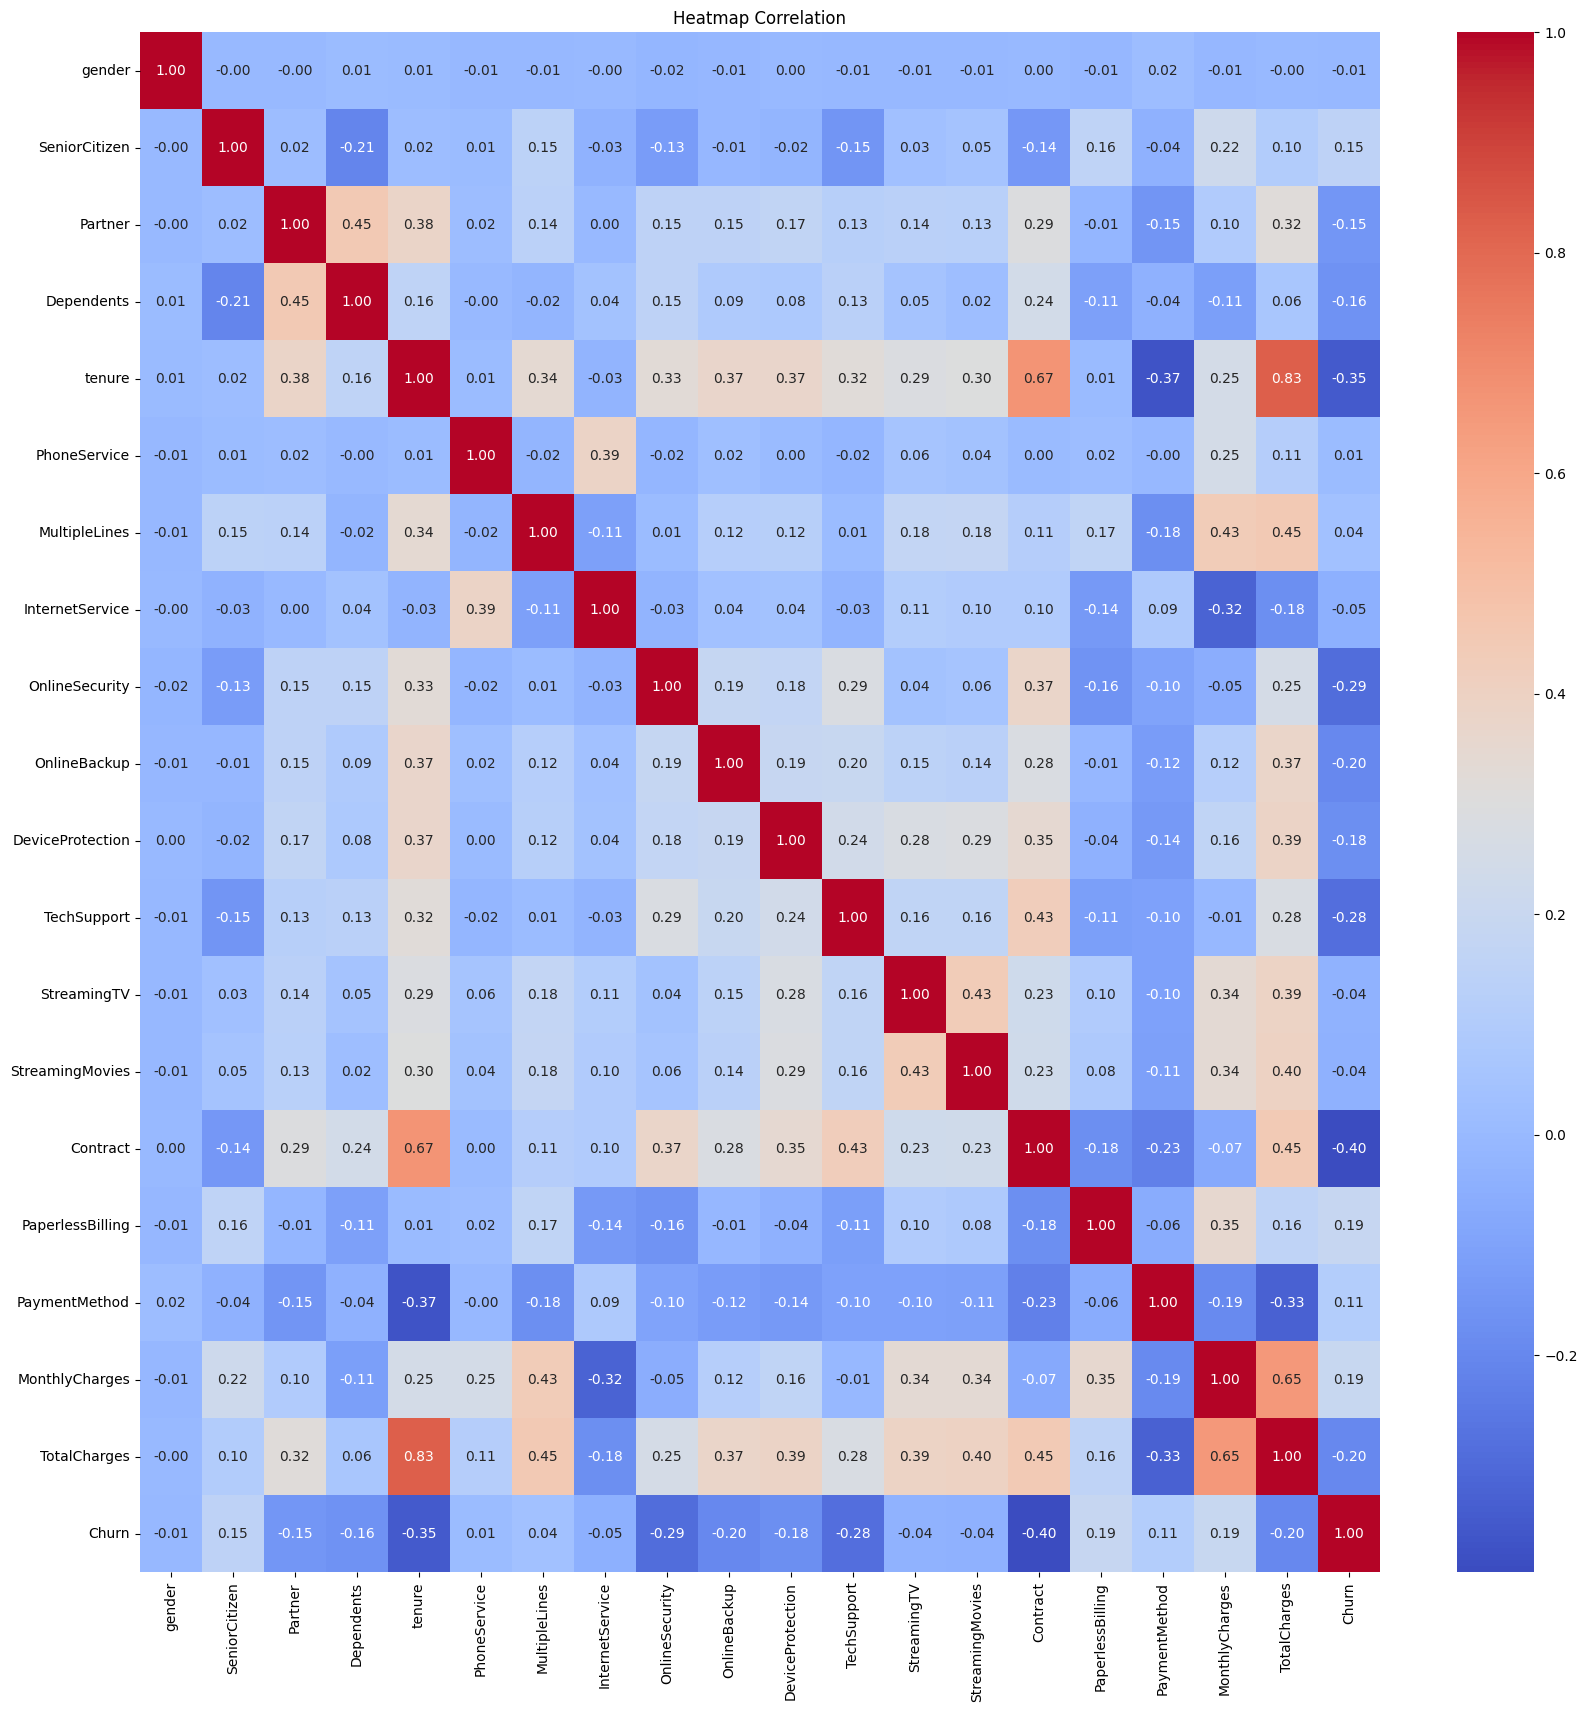

In [61]:
#Temporary Encoded
from sklearn.preprocessing import LabelEncoder
df_encode=df.copy()
col=['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod','Churn']

for i in col:
    le=LabelEncoder()
    df_encode[i]=le.fit_transform(df_encode[i])
plt.figure(figsize=(20,20))
sns.heatmap(df_encode.corr(),annot=True,fmt='.2f',cmap='coolwarm',)
plt.title('Heatmap Correlation')
plt.show()

#Preprocessing

#Encoding

In [62]:
from sklearn.preprocessing import LabelEncoder
col=['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod','Churn']

for i in col:
    le=LabelEncoder()
    df[i]=le.fit_transform(df[i])

#Splitting

In [63]:
X=df.drop('Churn',axis=1)
Y=df['Churn']

In [64]:
from sklearn.model_selection import train_test_split as tts
X_train,X_test,Y_train,Y_test=tts(X,Y,random_state=1,test_size=0.3)

#Scaling

In [65]:
from sklearn.preprocessing import StandardScaler
col=['tenure','MonthlyCharges','TotalCharges']
ss=StandardScaler()
X_train[col]=ss.fit_transform(X_train[col])
X_test[col]=ss.transform(X_test[col])

#Addressing Class Imbalance with SMOTE

In [66]:
Y_train.value_counts()

Churn
0    3589
1    1341
Name: count, dtype: int64

In [67]:
from imblearn.over_sampling import SMOTE
sm=SMOTE(random_state=42)
X_train,Y_train=sm.fit_resample(X_train,Y_train)

In [68]:
print(Y_train.value_counts())

Churn
0    3589
1    3589
Name: count, dtype: int64


#Modelling

Logistic Regression

In [69]:
from sklearn.linear_model import LogisticRegression 

In [70]:
log=LogisticRegression()
log.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


RandomForestClassifier

In [71]:
from sklearn.ensemble import RandomForestClassifier

In [72]:
rm=RandomForestClassifier(n_estimators=100,
                          random_state=42)
rm.fit(X_train,Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Xgboost Classifier

In [73]:
from xgboost import XGBClassifier

In [74]:
xgb=XGBClassifier(n_estimators=200,
                  learning_rate=0.1,
                  random_state=42,
                  max_depth=5,
                  sub_sample=0.8)
xgb.fit(X_train,Y_train)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [02:21:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "sub_sample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


#Evaluation

In [75]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [76]:
models = {
    'Logistic Regression': log,
    'Random Forest': rm,
    'XGBoost': xgb
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy_score(Y_test, y_pred):.2f}")
    print(f"Classification_rep:{classification_report(Y_test, y_pred)}")
    print(f"Confusion_mat:{confusion_matrix(Y_test,y_pred)}")
    print("="*50)

Model: Logistic Regression
Accuracy: 0.76
Classification_rep:              precision    recall  f1-score   support

           0       0.93      0.74      0.82      1585
           1       0.51      0.82      0.63       528

    accuracy                           0.76      2113
   macro avg       0.72      0.78      0.72      2113
weighted avg       0.82      0.76      0.77      2113

Confusion_mat:[[1165  420]
 [  94  434]]
Model: Random Forest
Accuracy: 0.78
Classification_rep:              precision    recall  f1-score   support

           0       0.89      0.81      0.85      1585
           1       0.55      0.69      0.61       528

    accuracy                           0.78      2113
   macro avg       0.72      0.75      0.73      2113
weighted avg       0.80      0.78      0.79      2113

Confusion_mat:[[1285  300]
 [ 162  366]]
Model: XGBoost
Accuracy: 0.77
Classification_rep:              precision    recall  f1-score   support

           0       0.89      0.78      0.83 

Feature Importance

LogisticRegression

In [77]:
log.coef_

array([[-0.33081052, -0.23753902, -0.20445697, -0.54667668, -1.65911815,
        -1.01248592,  0.06137784,  0.17961584, -0.31376629, -0.15853379,
        -0.12944639, -0.273827  ,  0.00665896,  0.04053173, -0.95971383,
         0.02465374, -0.09563826,  0.62704118,  1.06366921]])

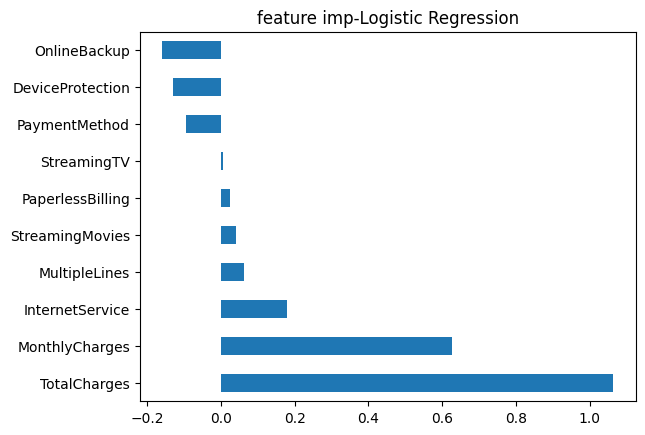

In [78]:
feat_imp_log=pd.Series(log.coef_[0],index=X.columns)
feat_imp_log.nlargest(10).plot(kind='barh')
plt.title('feature imp-Logistic Regression')
plt.show()

RandomForest

In [79]:
rm.feature_importances_

array([0.02451452, 0.0149373 , 0.02274509, 0.02326845, 0.15783441,
       0.00647575, 0.02190555, 0.02403557, 0.06063186, 0.02734249,
       0.02181262, 0.05483365, 0.01578362, 0.0170422 , 0.12653925,
       0.02187595, 0.04967931, 0.15636286, 0.15237955])

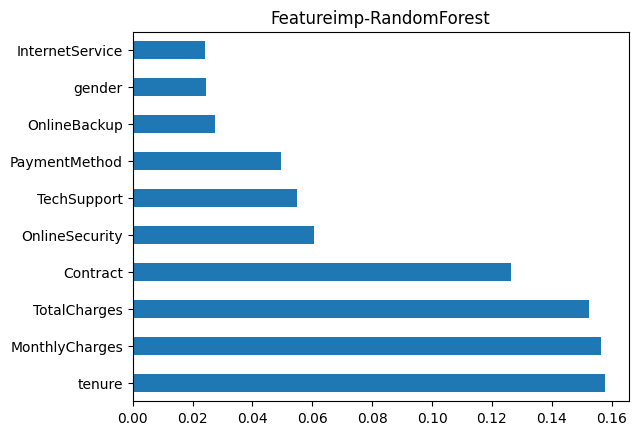

In [80]:
feat_imp_rf=pd.Series(rm.feature_importances_,index=X.columns)
feat_imp_rf.nlargest(10).plot(kind='barh')
plt.title('Featureimp-RandomForest')
plt.show()

XGBoost

In [81]:
xgb.feature_importances_

array([0.0204443 , 0.01680056, 0.01662415, 0.04127573, 0.03799023,
       0.03045399, 0.03064817, 0.03117525, 0.07798897, 0.02228095,
       0.01660457, 0.05390437, 0.01931757, 0.03256504, 0.4604588 ,
       0.01675919, 0.02759936, 0.02815162, 0.01895723], dtype=float32)

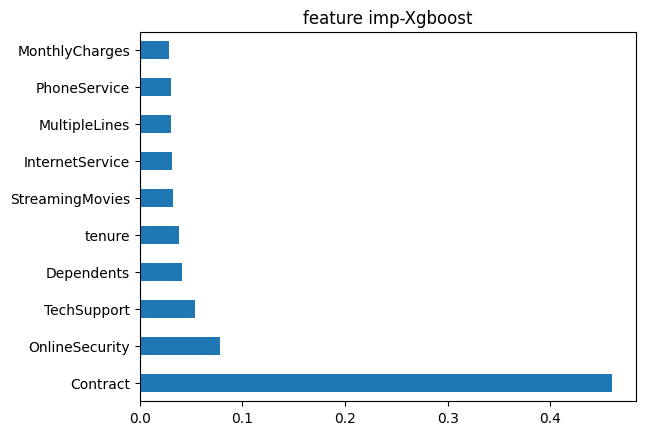

In [82]:
feat_imp_xgb=pd.Series(xgb.feature_importances_,index=X.columns)
feat_imp_xgb.nlargest(10).plot(kind='barh')
plt.title('feature imp-Xgboost')
plt.show()

#Business Insights

## 📊 Business Insights

### 1. Contract Type — Most Important Feature
Month-to-month customers churn 3x more than 
2-year contract customers. 
- Key Action: Offer discounts to switch customers 
  from monthly to long-term contracts.

### 2. Tenure — New Customers At Risk
Customers with tenure less than 12 months churn 
the most. New customers are most vulnerable.
- Key Action: Improve onboarding experience and 
  offer loyalty rewards in first 6 months.

### 3. Monthly Charges — High Charges = High Churn
Customers paying higher monthly charges are more 
likely to churn — possibly due to better offers 
from competitors.
- Key Action: Review pricing strategy and offer 
  personalized discounts to high-paying customers.

### 4. Internet Service — Fiber Optic Users Churn More
Fiber optic internet users churn more than DSL users 
despite paying more.
- Key Action: Improve fiber optic service quality 
  and customer support.

### 5. Payment Method
Electronic check users churn the most compared to 
auto-payment customers.
- Key Action: Incentivize customers to switch to 
  automatic payment methods.

### 6. Overall Recommendation
Focus on these 3 key areas:
- 📋 Convert month-to-month to long-term contracts
- 🎯 Target new customers (tenure < 12 months)
- 💰 Review pricing for high monthly charge customers

In [83]:
import joblib
joblib.dump(log,'logistic_model.pkl')
joblib.dump(rm,'random_forest.pkl')
joblib.dump(xgb,'xgb.pkl')
joblib.dump(ss,'scaler.pkl')

['scaler.pkl']